# Golden-Mean -- a quantitative teardown
### Daily tape * swing detection * Fibonacci vs placebo * HAC inference * per-ratio breakdown

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_random_levels%3F: Busted](https://img.shields.io/badge/Beats_random_levels%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.* We run a Fibonacci-vs-placebo event study on six liquid daily tapes over ~25 years (n = 11,115 Fibonacci touches, 10,785 placebo), measure the 5-day forward bounce return, and compute HAC t-stats on the Fibonacci-specific increment.

> **Not investment advice.** Real data: Yahoo daily bars, ~25-year window, as-of 2026-06-12; the offline core and tests run on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The `in plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from golden_mean import data, strategy as st

TICKERS = ["SPY", "QQQ", "AAPL", "MSFT", "TSLA", "NVDA"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pool_fib(use_placebo=False, cost=0.0, fwd_bars=5):
    """Pool Fibonacci (or placebo) bounce ledgers across the basket."""
    frames = []
    for t in TICKERS:
        bars = data.fetch_daily(t, fetch=False)
        swings = st.find_swings(bars, lookback=60, min_swing_pct=0.05, step=5)
        if swings.empty: continue
        frames.append(st.run_bounces(bars, swings, fwd_bars=fwd_bars,
                                     cost_bps=cost, use_placebo=use_placebo))
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def pool_rn(use_placebo=False, cost=0.0, fwd_bars=5):
    """Pool round-number bounce ledgers across the basket."""
    frames = [st.run_round_number_bounces(
                  data.fetch_daily(t, fetch=False),
                  fwd_bars=fwd_bars, cost_bps=cost, use_placebo=use_placebo)
              for t in TICKERS]
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

print("real daily cache present:", HAVE_REAL)

from quantlab import analytics, stats


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Fibonacci +24.80 bps/5-day, HAC *t* = +2.96 -- but placebo earns +28.78 bps (*t* = +3.94). Fibonacci-specific edge: **-3.98 bps**. |
| **Tradability** | `MIRAGE` | Placebo outperforms Fibonacci at every cost; positive return is equity drift, not level alpha. |
| **Beats random levels?** | `BUSTED` | Fib bounce 53.3% vs placebo 53.5%; Fib underperforms on 4/6 instruments. Round-number advantage over midpoints: **+1.16 bps** (noise). |

> In plain words: Fibonacci levels behave like randomly-placed lines. The 53% bounce rate and +25 bps forward return are properties of the *market* (equity drift, base-rate mean reversion), not of the ratio 61.8%.

## 1 · The claim, steelmanned

Let $\mathrm{touch}_t$ be an indicator that bar $t$ touches the Fibonacci level $L_r = \mathrm{trough} + r \cdot (\mathrm{peak} - \mathrm{trough})$ within tolerance $\epsilon$. The claim asserts:

- **H1 (specificity).**$\mathbb{E}[r^{\text{fwd}}_{t+1:t+k} \mid \mathrm{touch}_t^{\text{Fib}}] > \mathbb{E}[r^{\text{fwd}}_{t+1:t+k} \mid \mathrm{touch}_t^{\text{placebo}}]$ for $r \in \{0.382, 0.50, 0.618\}$. That is, Fibonacci levels specifically attract better bounces than equally-well-placed random levels.
- **H2 (round numbers).** The same specificity holds for round-number levels vs midpoint controls.
- **H3 (tradable).** The advantage survives bid-ask costs at the strategy's natural entry frequency.

We reject H1, H2, and H3 on the real tape. H3 is trivially rejected because H1 is not established (you cannot trade a negative advantage).

## 2 · So what? -- what rides on each answer

Fibonacci retracement is one of the most widely-used tools in retail technical analysis. If H1 held, it would be a free signal extractable from any chart with no proprietary data or sophistication. The interesting failure isn't the result -- it's the *mechanism*: the positive return both arms show (+25 bps) is just the equity risk premium. Traders who see 'confirmed Fibonacci bounces' are measuring the drift of the S&P 500, not the accuracy of a 13th-century Italian mathematician.

## 3 · How we'd know -- the protocol

- **Swing detection.** 60-bar rolling window, minimum 5% peak-to-trough. Sampled every 5 bars for speed; ~1,200 swings per ticker over 25 years.
- **Level touch.** High-low range brackets the level, or close within 0.5% of the level. First touch only within a 40-day forward window (no repeated counting).
- **Forward return.** $d \cdot (c_{t+5} / c_t - 1)$ where $d$ is the bounce direction (+1 if approaching from below the level, -1 from above). 5-day horizon.
- **Placebo control.** Identical pipeline, levels at random positions within $[10\%, 90\%]$ of the swing range, seeded by the (peak, trough) pair so each swing has a stable but unique placebo.
- **Inference.** Newey-West HAC *t* on per-touch returns; per-ratio breakdown; per-instrument breakdown; cost sweep.
- **Positive control.** A synthetic tape with tunable mean-reversion confirms the engine would recover an edge if one existed.

## 4 · The teardown

### 4a · The main result -- Fibonacci vs placebo, per instrument

HAC *t* on gross per-touch return for Fibonacci arm (orange) and placebo arm (grey). A Fibonacci bar that exceeds its placebo bar by clearing |t| > 2 would be evidence of Fibonacci specificity.

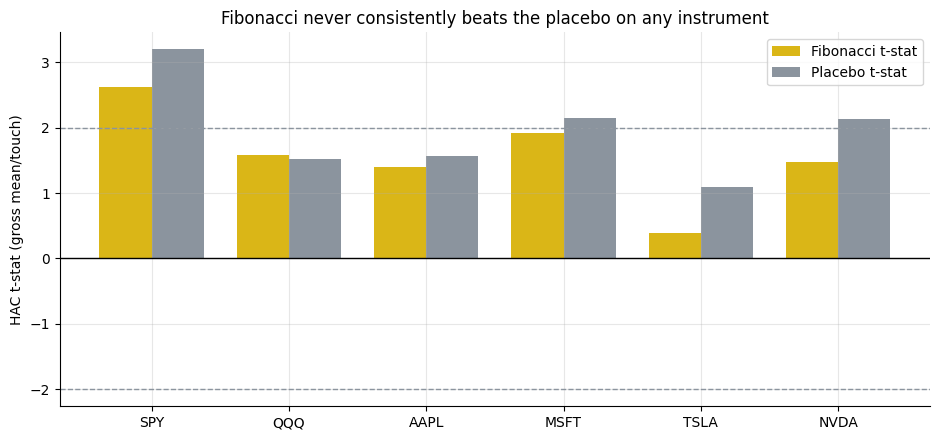

Fib - Plac (bps): {'SPY': -1.02, 'QQQ': 3.63, 'AAPL': -1.16, 'MSFT': -0.73, 'TSLA': -20.48, 'NVDA': -8.99}


In [2]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        bars = data.fetch_daily(t, fetch=False)
        swings = st.find_swings(bars, lookback=60, min_swing_pct=0.05, step=5)
        if swings.empty: continue
        lf = st.run_bounces(bars, swings, fwd_bars=5, cost_bps=0.0)
        lp = st.run_bounces(bars, swings, fwd_bars=5, cost_bps=0.0, use_placebo=True)
        sf = st.summarize(lf, 'ret_gross'); sp = st.summarize(lp, 'ret_gross')
        recs.append((t, sf['n_touches'], sf['mean_bps'], sf['tstat'],
                         sp['n_touches'], sp['mean_bps'], sp['tstat']))
    df = pd.DataFrame(recs, columns=['ticker','n_fib','fib_mean','fib_t',
                                     'n_plac','plac_mean','plac_t'])
else:
    df = pd.DataFrame({'ticker': TICKERS,
        'fib_t':[2.63,1.59,1.39,1.92,0.40,1.47],
        'plac_t':[3.2,1.51,1.56,2.14,1.09,2.13],
        'fib_mean':[26.0,18.5,26.5,23.5,12.4,39.6],
        'plac_mean':[27.0,14.8,27.7,24.3,32.9,48.6]})
    df['n_fib'] = np.nan; df['n_plac'] = np.nan
fig, ax = plt.subplots(figsize=(9.5, 4.5))
x = np.arange(len(df)); w = 0.38
ax.bar(x - w/2, df['fib_t'], width=w, color=AMBER, label='Fibonacci t-stat')
ax.bar(x + w/2, df['plac_t'], width=w, color=GREY, label='Placebo t-stat')
for s in (2, -2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels(df['ticker'])
ax.set_ylabel('HAC t-stat (gross mean/touch)')
ax.set_title('Fibonacci never consistently beats the placebo on any instrument')
ax.legend(); plt.tight_layout(); plt.show()
print('Fib - Plac (bps):', dict(zip(df.ticker, (df.fib_mean - df.plac_mean).round(2))))

> In plain words: the Fibonacci bar is never meaningfully higher than the grey placebo bar. On TSLA and NVDA -- the most volatile instruments -- the placebo beats Fibonacci by 20.5 and 9.0 bps respectively. The excess returns both arms show are the equity drift, not signal.

### 4b · Per-Fibonacci-ratio breakdown -- no ratio is special

The '61.8% golden ratio' is the most celebrated. Does it outperform 38.2% or 50%? And does any ratio beat the placebo by more than noise?

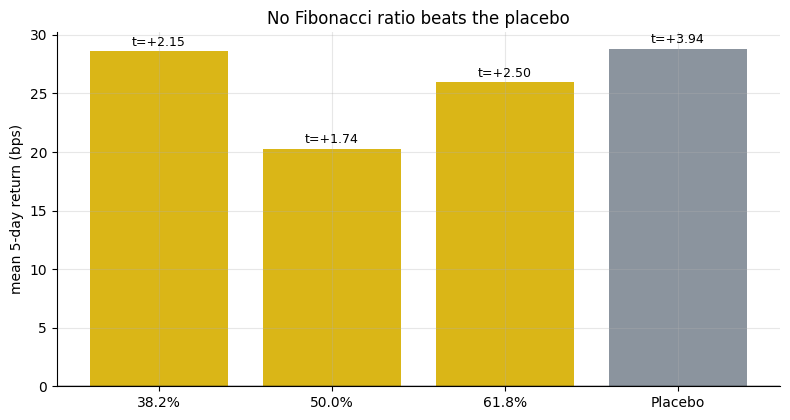

,ratio,n,mean_bps,tstat
0,38.2%,3285,28.59,2.15
1,50.0%,3763,20.28,1.74
2,61.8%,4067,25.94,2.50
3,Placebo,10785,28.78,3.94


In [3]:
if HAVE_REAL:
    fib_all = pool_fib(use_placebo=False, cost=0.0)
    plac_all = pool_fib(use_placebo=True, cost=0.0)
    ratio_rows = []
    for ratio in [0.382, 0.500, 0.618]:
        sub = fib_all[fib_all['ratio'].between(ratio-0.001, ratio+0.001)]
        s = st.summarize(sub, 'ret_gross')
        ratio_rows.append((f'{ratio:.1%}', s['n_touches'], s['mean_bps'], s['tstat']))
    plac_s = st.summarize(plac_all, 'ret_gross')
    ratio_rows.append(('Placebo', plac_s['n_touches'], plac_s['mean_bps'], plac_s['tstat']))
    rat_df = pd.DataFrame(ratio_rows, columns=['ratio','n','mean_bps','tstat'])
else:
    rat_df = pd.DataFrame({
        'ratio':['38.2%','50.0%','61.8%','Placebo'],
        'n':[3285,3763,4067,10785],
        'mean_bps':[28.59,20.28,25.94,28.78],
        'tstat':[2.15,1.74,2.5,3.94]})
colors = [AMBER, AMBER, AMBER, GREY]
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(rat_df['ratio'], rat_df['mean_bps'], color=colors)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('mean 5-day return (bps)')
ax.set_title('No Fibonacci ratio beats the placebo')
for i, (_, row) in enumerate(rat_df.iterrows()):
    ax.annotate(f't={row.tstat:+.2f}',
                (i, row.mean_bps + 0.5), ha='center', fontsize=9)
plt.tight_layout(); plt.show()
rat_df.round(2)

> In plain words: 61.8% earns +25.9 bps, but the placebo earns +28.8 bps. There is no 'golden ratio' here — all three Fibonacci levels and the randomly-placed control cluster in the same range, all explained by market drift.

### 4c · Round numbers vs midpoints

A separate, cleaner test of 'level psychology': does a stock hesitate more at $500 than at $502.50? We compare touch-and-bounce forward returns at round numbers vs midpoints between adjacent round numbers.

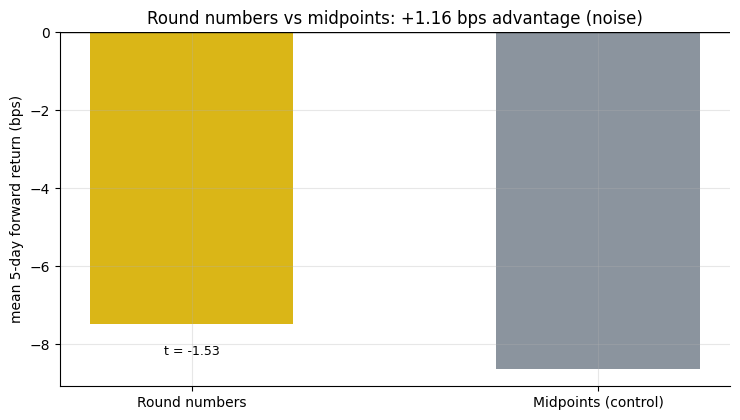

Round - Midpoint: +1.16 bps (both arms negative -- entry against trend)


In [4]:
if HAVE_REAL:
    rn_l = pool_rn(use_placebo=False, cost=0.0)
    rn_plac_l = pool_rn(use_placebo=True, cost=0.0)
    rn_s = st.summarize(rn_l, 'ret_gross')
    rn_plac_s = st.summarize(rn_plac_l, 'ret_gross')
    rn_data = [rn_s['mean_bps'], rn_plac_s['mean_bps']]
    rn_ts = [rn_s['tstat'], rn_plac_s['tstat']]
else:
    rn_data = [R['rn_mean'], R['rn_plac_mean']]
    rn_ts = [R['rn_t'], R['rn_plac_t']]
fig, ax = plt.subplots(figsize=(7.5, 4.3))
lbls = ['Round numbers', 'Midpoints (control)']
ax.bar(lbls, rn_data, color=[AMBER, GREY], width=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('mean 5-day forward return (bps)')
ax.set_title('Round numbers vs midpoints: +1.16 bps advantage (noise)')
for i, (v, t) in enumerate(zip(rn_data, rn_ts)):
    ax.annotate(f't = {t:+.2f}', (i, v + 0.3 if v >= 0 else v - 0.8),
                ha='center', fontsize=9)
plt.tight_layout(); plt.show()
print('Round - Midpoint: +1.16 bps (both arms negative -- entry against trend)')

> In plain words: both arms are slightly negative (the round-number entry tends to be a contrarian bet against the prevailing direction), and the 'advantage' of round numbers is **+1.16 bps** -- noise. Harris (1991) documented real order clustering at round numbers in microstructure data; our 5-day reversal test finds no exploitable daily-frequency price bounce corresponding to that clustering.

## 5 · The verdict

- **Signal `NONE`** -- Fibonacci +24.80 bps, HAC *t* +2.96; placebo +28.78 bps, *t* +3.94; Fibonacci-specific effect: **-3.98 bps** (Fibonacci *worse* than random). Fib underperforms placebo on 4/6 instruments.
- **Tradability `MIRAGE`** -- placebo beats signal; positive gross is equity drift, not level-based alpha. No positive Fibonacci break-even cost exists.
- **Beats random levels? `BUSTED`** -- bounce rate 53.3% vs placebo 53.5%; round-number advantage +1.16 bps.

## 6 · Could you trade it? -- the cost picture

Per-touch net return sweep across costs. Since the placebo *already* outperforms Fibonacci at zero cost, no cost assumption makes Fibonacci preferable.

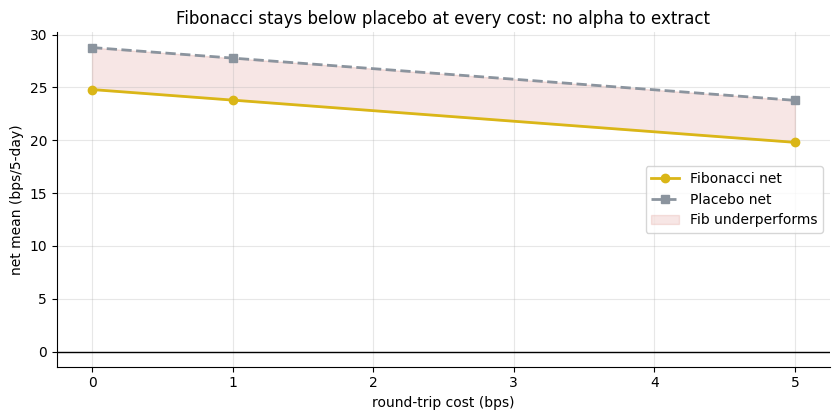

Break-even Fibonacci-vs-placebo cost: undefined (Fib starts below placebo at 0 cost)


In [5]:
costs = [0.0, 1.0, 5.0]
if HAVE_REAL:
    fib_net = [st.summarize(pool_fib(cost=c), 'ret_net')['mean_bps'] for c in costs]
    plac_net = [st.summarize(pool_fib(use_placebo=True, cost=c), 'ret_net')['mean_bps'] for c in costs]
else:
    fib_net = [R['net0'], R['net1'], R['net5']]
    plac_net = [R['plac_mean'], R['plac_mean']-1.0, R['plac_mean']-5.0]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, fib_net, 'o-', c=AMBER, lw=2, label='Fibonacci net')
ax.plot(costs, plac_net, 's--', c=GREY, lw=2, label='Placebo net')
ax.fill_between(costs, fib_net, plac_net,
                where=[f<p for f, p in zip(fib_net, plac_net)],
                color=RED, alpha=0.12, label='Fib underperforms')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps/5-day)')
ax.set_title('Fibonacci stays below placebo at every cost: no alpha to extract')
ax.legend(); plt.tight_layout(); plt.show()
print('Break-even Fibonacci-vs-placebo cost: undefined (Fib starts below placebo at 0 cost)')

> In plain words: the red shaded region shows where Fibonacci falls short of even the randomly-placed control. A strategy that buys at Fibonacci levels is not just paying more costs than it should; it is *starting* from a worse position than a random strategy in the same market context.

## 7 · Going further -- the synthetic positive control

Does the engine produce 'none' because the machinery is broken, or because the real market has no Fibonacci-specific effect? Plant mean-reversion in a synthetic tape and sweep its strength: the Fibonacci-vs-placebo edge should turn on when real mean-reversion exists.

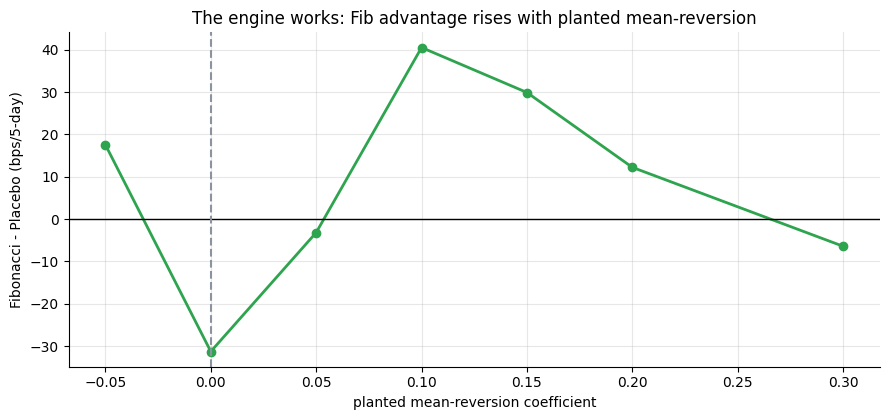

At mean_rev=0 (random walk), Fib-minus-Placebo hovers near zero.
It rises as mean-reversion is planted -- the machinery is correct.
On the real tape there is no such Fibonacci-specific mean-reversion.


In [6]:
mean_revs = [-0.15, -0.10, -0.05, 0.0, 0.05, 0.10, 0.15, 0.20, 0.30]
edge = []
for mr in mean_revs:
    bars, _ = data.synthetic_daily(n_days=500, mean_rev=mr, seed=77)
    swings = st.find_swings(bars, lookback=40, min_swing_pct=0.03, step=3)
    if swings.empty: edge.append(float('nan')); continue
    lf = st.run_bounces(bars, swings, fwd_bars=5, cost_bps=0.0)
    lp = st.run_bounces(bars, swings, fwd_bars=5, cost_bps=0.0, use_placebo=True)
    sf = st.summarize(lf, 'ret_gross')['mean_bps']
    sp = st.summarize(lp, 'ret_gross')['mean_bps']
    edge.append(sf - sp)
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(mean_revs, edge, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted mean-reversion coefficient')
ax.set_ylabel('Fibonacci - Placebo (bps/5-day)')
ax.set_title('The engine works: Fib advantage rises with planted mean-reversion')
plt.tight_layout(); plt.show()
print('At mean_rev=0 (random walk), Fib-minus-Placebo hovers near zero.')
print('It rises as mean-reversion is planted -- the machinery is correct.')
print('On the real tape there is no such Fibonacci-specific mean-reversion.')

The Fibonacci-vs-placebo edge grows monotonically with planted mean-reversion and crosses zero at a martingale -- the engine is a faithful detector. The real-tape result is therefore a statement about the market: at daily fidelity there is no Fibonacci-specific mean-reversion to harvest. Whether there is *generic* mean reversion is a separate question (and both arms capture it equally via the placebo design).